In [4]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
SEED= 93499


Loading and Exploring the data

In [5]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 17.6 MB


In [7]:
train_df.isna().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
train_df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [9]:
train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [10]:
#removing irrelevant features
train_df = train_df.drop(['id', 'CustomerId', 'Surname', ], axis=1)
test_df = test_df.drop(['id', 'CustomerId', 'Surname'], axis=1)
train_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [11]:
#seeing what the percentage of churned customers is
churned_percentage = train_df['Exited'].mean() * 100
print(f"Percentage of churned customers: {churned_percentage:.2f}%")

Percentage of churned customers: 21.16%


In [12]:
#transforming categorical features into numerical features
train_df = pd.get_dummies(train_df, columns=['Geography', 'Gender'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Geography', 'Gender'], drop_first=True)
train_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,668,33.0,3,0.00,2,1.0,0.0,181449.97,0,False,False,True
1,627,33.0,1,0.00,2,1.0,1.0,49503.50,0,False,False,True
2,678,40.0,10,0.00,2,1.0,0.0,184866.69,0,False,False,True
3,581,34.0,2,148882.54,1,1.0,1.0,84560.88,0,False,False,True
4,716,33.0,5,0.00,2,1.0,1.0,15068.83,0,False,True,True


In [16]:
test_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,586,23.0,2,0.00,2,0.0,1.0,160976.75,False,False,False
1,683,46.0,2,0.00,1,1.0,0.0,72549.27,False,False,False
2,656,34.0,7,0.00,2,1.0,0.0,138882.09,False,False,False
3,681,36.0,8,0.00,1,1.0,0.0,113931.57,False,False,True
4,752,38.0,10,121263.62,1,1.0,0.0,139431.00,True,False,True


In [17]:
#generate train test splits
X_train, X_test, y_train, y_test = train_test_split(train_df.drop('Exited', axis=1), train_df['Exited'], test_size=0.2, random_state=SEED)

In [24]:
#creatin the base model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=SEED)
model.fit(X_train, y_train)
#predict
y_pred = model.predict(X_test)


In [25]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test, y_pred))

0.8592116823704062


In [32]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 93499,
 'verbose': 0,
 'warm_start': False}

In [30]:
params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 4, 5, 8, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': np.linspace(0.0001, 1, 10).tolist()
}

In [36]:
grid_model = RandomizedSearchCV(estimator=model, param_distributions=params, cv=5, n_iter=20,verbose=2, random_state=SEED)
grid_model.fit(X_train, y_train)
print(grid_model.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=10, min_samples_leaf=0.0001, min_samples_split=5, n_estimators=300; total time=  11.5s
[CV] END max_depth=10, min_samples_leaf=0.0001, min_samples_split=5, n_estimators=300; total time=  11.4s
[CV] END max_depth=10, min_samples_leaf=0.0001, min_samples_split=5, n_estimators=300; total time=  11.3s
[CV] END max_depth=10, min_samples_leaf=0.0001, min_samples_split=5, n_estimators=300; total time=  11.3s
[CV] END max_depth=10, min_samples_leaf=0.0001, min_samples_split=5, n_estimators=300; total time=  11.3s
[CV] END max_depth=8, min_samples_leaf=0.11120000000000001, min_samples_split=2, n_estimators=200; total time=   2.3s
[CV] END max_depth=8, min_samples_leaf=0.11120000000000001, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END max_depth=8, min_samples_leaf=0.11120000000000001, min_samples_split=2, n_estimators=200; total time=   2.4s
[CV] END max_depth=8, min_samples_leaf=0.1112000000000

/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
10 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/miniconda3/envs/cs178/lib/python3.14/site-packages

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 0.0001, 'max_depth': None}


In [37]:
#accuracy score
y_pred = grid_model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8644226982155301


In [83]:
#import confusion matrix and classification report
import copy

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_test1= copy.deepcopy(y_test)
y_pred1 = copy.deepcopy(y_pred)

[[24955  1129]
 [ 3630  3293]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     26084
           1       0.74      0.48      0.58      6923

    accuracy                           0.86     33007
   macro avg       0.81      0.72      0.75     33007
weighted avg       0.85      0.86      0.84     33007



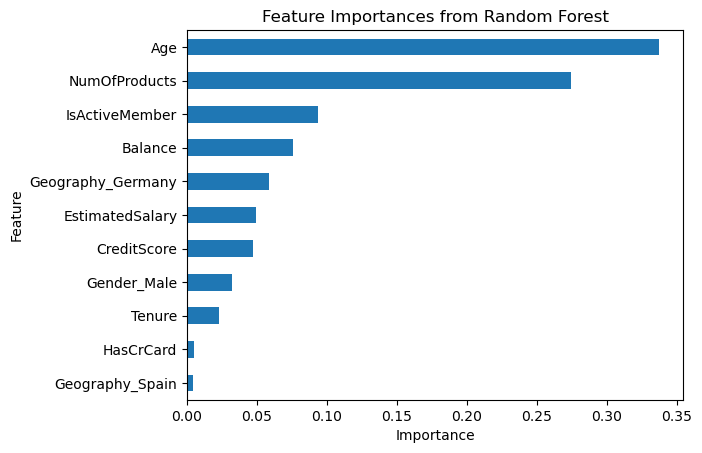

In [39]:
importances_rf = pd.Series(grid_model.best_estimator_.feature_importances_, index=X_train.columns)
importances_rf.sort_values().plot(kind='barh')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

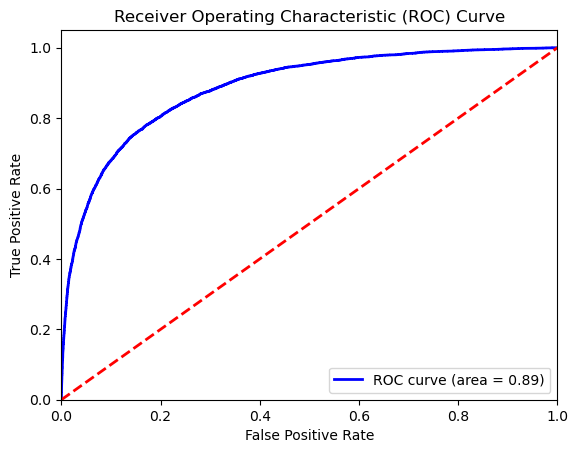

In [40]:
#ROC Curve
from sklearn.metrics import roc_curve, auc
y_prob = grid_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()  

accuracy score decent, precision decent, recall not that good


Iteration 2 of random forest model
class_weight = "Balanced"
Remove Geography, Credit card, tenure, gender


In [41]:
train_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,668,33.0,3,0.00,2,1.0,0.0,181449.97,0,False,False,True
1,627,33.0,1,0.00,2,1.0,1.0,49503.50,0,False,False,True
2,678,40.0,10,0.00,2,1.0,0.0,184866.69,0,False,False,True
3,581,34.0,2,148882.54,1,1.0,1.0,84560.88,0,False,False,True
4,716,33.0,5,0.00,2,1.0,1.0,15068.83,0,False,True,True


In [43]:
#removing irrelevant features and retraining the model
train_df = train_df.drop(['HasCrCard', 'Tenure', 'Gender_Male', 'Geography_Spain', 'Geography_Germany'], axis=1)
test_df = test_df.drop(['HasCrCard', 'Tenure', 'Gender_Male', 'Geography_Spain', 'Geography_Germany'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(train_df.drop('Exited', axis=1), train_df['Exited'], test_size=0.2, random_state=SEED)

In [44]:
#more grid search
params2 = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None, 4, 5, 8, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': np.linspace(0.0001, 0.3, 5).tolist()
}

grid_model2 = RandomizedSearchCV(estimator=model, param_distributions=params2, cv=5, n_iter=50,verbose=2, random_state=SEED)
grid_model2.fit(X_train, y_train)
print(grid_model2.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=8, min_samples_leaf=0.15005, min_samples_split=2, n_estimators=400; total time=   3.8s
[CV] END max_depth=8, min_samples_leaf=0.15005, min_samples_split=2, n_estimators=400; total time=   3.7s
[CV] END max_depth=8, min_samples_leaf=0.15005, min_samples_split=2, n_estimators=400; total time=   3.8s
[CV] END max_depth=8, min_samples_leaf=0.15005, min_samples_split=2, n_estimators=400; total time=   3.8s
[CV] END max_depth=8, min_samples_leaf=0.15005, min_samples_split=2, n_estimators=400; total time=   3.8s
[CV] END max_depth=None, min_samples_leaf=0.15005, min_samples_split=5, n_estimators=200; total time=   1.9s
[CV] END max_depth=None, min_samples_leaf=0.15005, min_samples_split=5, n_estimators=200; total time=   1.9s
[CV] END max_depth=None, min_samples_leaf=0.15005, min_samples_split=5, n_estimators=200; total time=   2.1s
[CV] END max_depth=None, min_samples_leaf=0.15005, min_samples_split=5, n_estimat

In [45]:
print(grid_model2.best_estimator_)

RandomForestClassifier(max_depth=10, min_samples_leaf=0.0001,
                       min_samples_split=5, n_estimators=400,
                       random_state=93499)


In [46]:
y_pred = grid_model2.predict(X_test)
print(accuracy_score(y_test, y_pred))


0.8558184627503257


In [47]:
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     26084
           1       0.74      0.48      0.58      6923

    accuracy                           0.86     33007
   macro avg       0.81      0.72      0.75     33007
weighted avg       0.85      0.86      0.84     33007



low recall for churners

In [48]:
#Testing lower specificity threshold
# Get probabilities instead of hard predictions
y_proba = grid_model2.best_estimator_.predict_proba(X_test)[:, 1]

# Apply lower threshold
y_pred_adjusted = (y_proba >= 0.35).astype(int)

# Evaluate with new threshold
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     26084
           1       0.63      0.64      0.63      6923

    accuracy                           0.84     33007
   macro avg       0.76      0.77      0.77     33007
weighted avg       0.85      0.84      0.84     33007



testing for the best threshold

In [49]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.125,0.15,0.175,0.2,0.25,0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    print(f"Threshold {t} | Precision: {precision_score(y_test, preds):.2f} | Recall: {recall_score(y_test, preds):.2f}")

Threshold 0.125 | Precision: 0.40 | Recall: 0.89
Threshold 0.15 | Precision: 0.43 | Recall: 0.87
Threshold 0.175 | Precision: 0.44 | Recall: 0.85
Threshold 0.2 | Precision: 0.48 | Recall: 0.82
Threshold 0.25 | Precision: 0.54 | Recall: 0.75
Threshold 0.3 | Precision: 0.59 | Recall: 0.69
Threshold 0.35 | Precision: 0.63 | Recall: 0.64
Threshold 0.4 | Precision: 0.67 | Recall: 0.59
Threshold 0.45 | Precision: 0.71 | Recall: 0.53
Threshold 0.5 | Precision: 0.74 | Recall: 0.48


best model was the first iteration with 87% accuracy
will now fit logistic regression model to see if it does better

In [50]:
from sklearn.linear_model import LogisticRegression
df = pd.read_csv('train.csv')
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [51]:
#remove irrelevant features
df = df.drop(['id', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [52]:
df= pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,668,33.0,3,0.00,2,1.0,0.0,181449.97,0,False,False,True
1,627,33.0,1,0.00,2,1.0,1.0,49503.50,0,False,False,True
2,678,40.0,10,0.00,2,1.0,0.0,184866.69,0,False,False,True
3,581,34.0,2,148882.54,1,1.0,1.0,84560.88,0,False,False,True
4,716,33.0,5,0.00,2,1.0,1.0,15068.83,0,False,True,True


In [53]:
X = df.drop('Exited', axis=1).values
y = df['Exited'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

logreg = LogisticRegression(random_state=SEED, max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
print(accuracy_score(y_test, y_pred_logreg))

0.834065501257309


In [60]:
#hyperparameter tuning for logistic regression
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(LogisticRegression(random_state=SEED, max_iter=1000), lr_params, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
best_logreg = grid_search.best_estimator_
y_pred_best_logreg = best_logreg.predict(X_test)
print("Test set accuracy:", accuracy_score(y_test, y_pred_best_logreg))

/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation score: 0.8341172826526619
Test set accuracy: 0.8340352046535583


/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


looks like the best model is still the first iteration of the random forest with 87% accuracy and 89% ROC_AUC, 75% precision

Trying KNN model 

In [63]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8463962189838519


In [64]:
#hyperparameter tuning for KNN
print(knn.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [66]:
params_knn = {
    'n_neighbors': np.arange(1, 20, 1).tolist(),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), params_knn, cv=5, scoring='accuracy', verbose=2)
grid_search_knn.fit(X_train, y_train)
print("Best KNN parameters:", grid_search_knn.best_params_)
print("Best KNN cross-validation score:", grid_search_knn.best_score_)
best_knn = grid_search_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)
print("Test set KNN accuracy:", accuracy_score(y_test, y_pred_best_knn))

Fitting 5 folds for each of 76 candidates, totalling 380 fits
[CV] END ...metric=euclidean, n_neighbors=1, weights=uniform; total time=   0.5s
[CV] END ...metric=euclidean, n_neighbors=1, weights=uniform; total time=   0.5s
[CV] END ...metric=euclidean, n_neighbors=1, weights=uniform; total time=   0.4s
[CV] END ...metric=euclidean, n_neighbors=1, weights=uniform; total time=   0.4s
[CV] END ...metric=euclidean, n_neighbors=1, weights=uniform; total time=   0.4s
[CV] END ..metric=euclidean, n_neighbors=1, weights=distance; total time=   0.5s
[CV] END ..metric=euclidean, n_neighbors=1, weights=distance; total time=   0.4s
[CV] END ..metric=euclidean, n_neighbors=1, weights=distance; total time=   0.4s
[CV] END ..metric=euclidean, n_neighbors=1, weights=distance; total time=   0.6s
[CV] END ..metric=euclidean, n_neighbors=1, weights=distance; total time=   0.5s
[CV] END ...metric=euclidean, n_neighbors=2, weights=uniform; total time=   0.6s
[CV] END ...metric=euclidean, n_neighbors=2, we

In [67]:
y_pred_train_knn = best_knn.predict(X_train)
print("KNN Training Accuracy:", accuracy_score(y_train, y_pred_train_knn))

KNN Training Accuracy: 0.8668605663992971


In [69]:
print(grid_search_knn.best_estimator_)

KNeighborsClassifier(metric='euclidean', n_neighbors=19)


In [70]:
#see if even more than 19 neighbors improves accuracy
params_knn_extended = {
    'n_neighbors': np.arange(19, 30, 1).tolist(),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']}

grid_search_knn_extended = GridSearchCV(KNeighborsClassifier(), params_knn_extended, cv=5, scoring='accuracy', verbose=2)
grid_search_knn_extended.fit(X_train, y_train)
print("Best KNN parameters (extended):", grid_search_knn_extended.best_params_)
print("Best KNN cross-validation score (extended):", grid_search_knn_extended.best_score_)
best_knn_extended = grid_search_knn_extended.best_estimator_
y_pred_best_knn_extended = best_knn_extended.predict(X_test)
print("Test set KNN accuracy (extended):", accuracy_score(y_test, y_pred_best_knn_extended))

Fitting 5 folds for each of 22 candidates, totalling 110 fits
[CV] END ..metric=euclidean, n_neighbors=19, weights=uniform; total time=   1.4s
[CV] END ..metric=euclidean, n_neighbors=19, weights=uniform; total time=   1.3s
[CV] END ..metric=euclidean, n_neighbors=19, weights=uniform; total time=   1.3s
[CV] END ..metric=euclidean, n_neighbors=19, weights=uniform; total time=   1.3s
[CV] END ..metric=euclidean, n_neighbors=19, weights=uniform; total time=   1.3s
[CV] END .metric=euclidean, n_neighbors=19, weights=distance; total time=   1.3s
[CV] END .metric=euclidean, n_neighbors=19, weights=distance; total time=   1.3s
[CV] END .metric=euclidean, n_neighbors=19, weights=distance; total time=   1.3s
[CV] END .metric=euclidean, n_neighbors=19, weights=distance; total time=   1.3s
[CV] END .metric=euclidean, n_neighbors=19, weights=distance; total time=   1.3s
[CV] END ..metric=euclidean, n_neighbors=20, weights=uniform; total time=   1.3s
[CV] END ..metric=euclidean, n_neighbors=20, we

In [72]:
print(grid_search_knn_extended.best_estimator_)

KNeighborsClassifier(metric='euclidean', n_neighbors=29, weights='distance')


In [73]:
print(accuracy_score(y_test, y_pred_best_knn_extended))

0.8583936740691368


In [74]:
print(confusion_matrix(y_test, y_pred_best_knn_extended))

[[24803  1281]
 [ 3393  3530]]


In [75]:
print(classification_report(y_test, y_pred_best_knn_extended))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91     26084
           1       0.73      0.51      0.60      6923

    accuracy                           0.86     33007
   macro avg       0.81      0.73      0.76     33007
weighted avg       0.85      0.86      0.85     33007



In [85]:
#Model Rankings:
print("Random Forest Accuracy:", '0.8644226982155301')
print("Random Forest Accuracy Iteration 2:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_best_logreg))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Best KNN Accuracy:", accuracy_score(y_test, y_pred_best_knn))    

Random Forest Accuracy: 0.8644226982155301
Random Forest Accuracy Iteration 2: 0.8558184627503257
Logistic Regression Accuracy: 0.8340352046535583
KNN Accuracy: 0.8463962189838519
Best KNN Accuracy: 0.8579998182203775


1st iteration Random forest is the best with 87% accuracy and 89% ROC_AUC and 74% precision.